=== RMS of Windowed Derivatives (1-second windows) ===
Polynomial method: -3.166125
Gradient method:   -5.234927
Central diff:      -5.234927

=== RMS of Full Derivative Signal ===
Polynomial method: -5.327179
Gradient method:   -5.430304

=== Statistics of Full Derivatives ===
Polynomial method:
  Mean: -0.576610
  Std:  5.295881
  Mean(abs): 4.503915

Gradient method:
  Mean: -0.478352
  Std:  5.409194
  Mean(abs): 4.647976


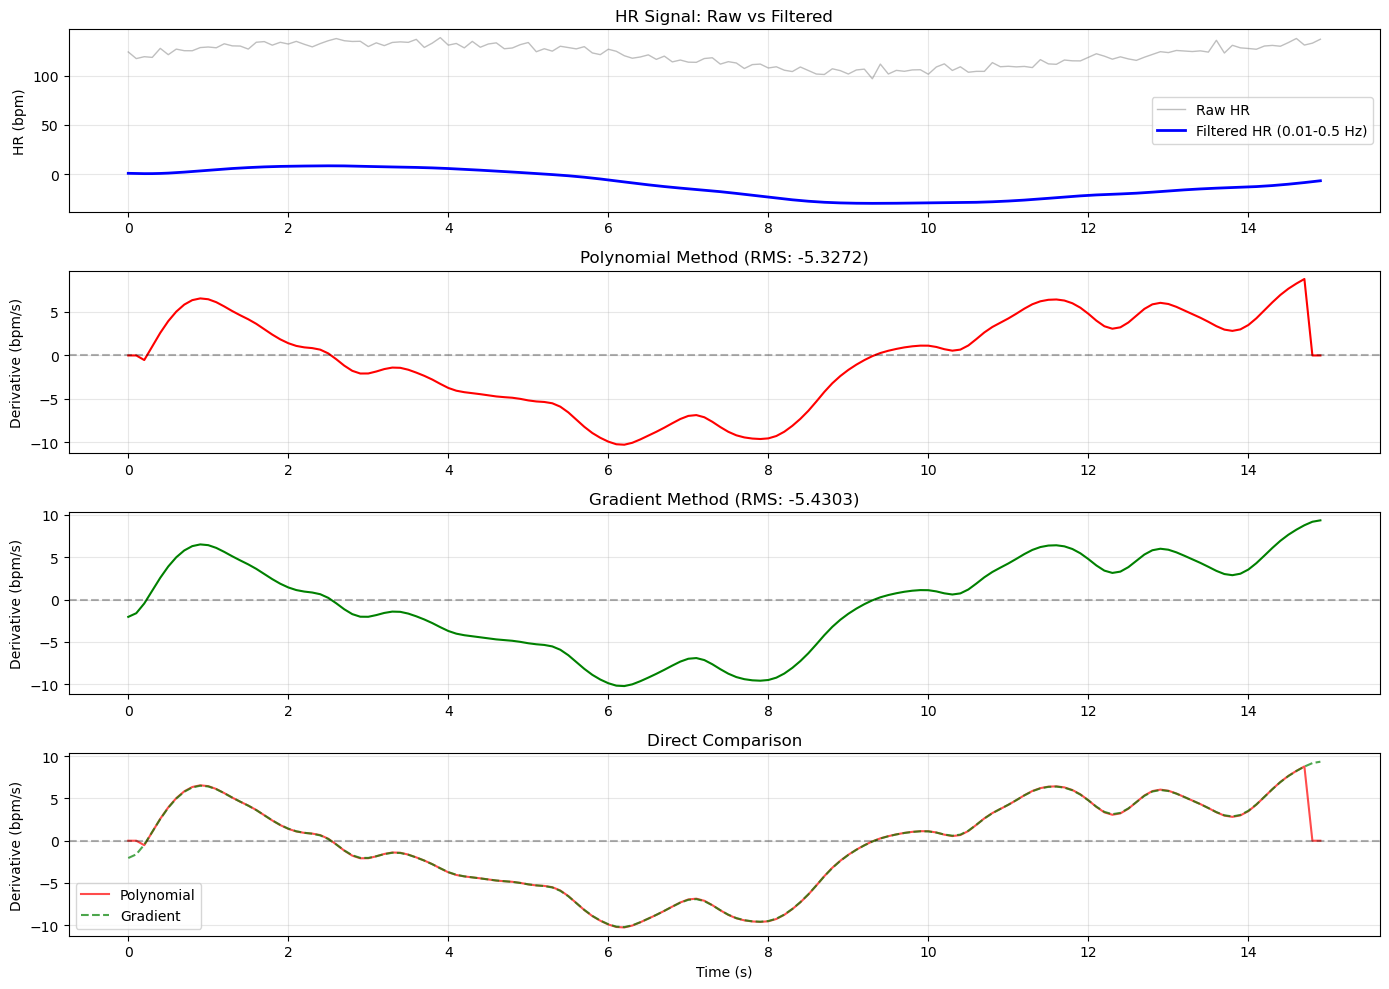


=== Key Insight ===
After bandpass filtering at 0.01-0.5 Hz, the signal is very smooth.
Derivatives should be small. If you're getting 0.2-0.3 with np.gradient
but expecting 0.1-0.2, the issue might be:
  1. The signal isn't properly filtered
  2. The window size for RMS is too small
  3. There's noise/artifacts in your actual HR data


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Simplified num_derivative function (corrected)
def num_derivative_fixed(time, x, ver):
    if ver.lower() == 'x_1':
        x = np.reshape(x, (-1, 1))
    else:
        raise ValueError('Not a valid version')
        
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    delta_t = np.mean(np.diff(time))
    W = 4
    N = 3
    K = round(W / 2)
    
    if len(x) < W + 1 or np.std(x) < 1e-12:
        return np.zeros_like(x)
    
    # Corrected: use unscaled indices
    A = np.linspace(-W, 0, W + 1) + K
    A = np.vstack([A**n for n in range(N+1)]).T
    R = np.zeros(N+1)
    R[1] = 1
    
    try:
        R = R @ np.linalg.pinv(A.T @ A) @ A.T
    except np.linalg.LinAlgError:
        return np.zeros_like(x)
    
    x_d = np.zeros_like(x)
    
    for i in range(W - K, len(x) - K):
        segment = x[i - W + K : i + K + 1, 0]
        if np.any(np.isnan(segment)):
            x_d[i, :] = 0.0
        else:
            x_d[i, :] = (R @ segment) / delta_t  # Corrected: divide by delta_t
    
    return x_d

# RMS function from your code
def rms(sig):
    mag = np.sqrt(np.mean(sig**2))
    direction = np.sign(np.mean(sig))
    return direction * mag

# Simulate realistic HR data
fs_hr_target = 10  # 10 Hz after interpolation
duration = 15  # 15-second bin
time_10hz = np.arange(0, duration, 1.0/fs_hr_target)

# Create realistic HR signal: baseline + slow variation + noise
baseline_hr = 120
slow_variation = 15 * np.sin(2 * np.pi * 0.08 * time_10hz)  # 0.08 Hz variation
noise = np.random.normal(0, 3, len(time_10hz))
hr_raw = baseline_hr + slow_variation + noise

# Apply bandpass filter (0.01-0.5 Hz) like in your code
low_hr = 0.01
high_hr = 0.5
nyquist_hr = fs_hr_target / 2
low_c_hr = low_hr / nyquist_hr
high_c_hr = high_hr / nyquist_hr
order_hr = 2
b_filt_hr, a_filt_hr = signal.butter(order_hr, [low_c_hr, high_c_hr], btype='band')
hr_filtered = signal.filtfilt(b_filt_hr, a_filt_hr, hr_raw)

# Now compute derivatives on this filtered signal
# Method 1: Your corrected polynomial method
deriv_poly = num_derivative_fixed(time_10hz, hr_filtered, 'x_1').flatten()

# Method 2: Simple gradient
deriv_gradient = np.gradient(hr_filtered, time_10hz)

# Method 3: Central difference with smoothing (more stable)
deriv_central = np.gradient(hr_filtered, 1/fs_hr_target)

# Simulate your windowing approach
window_sec_hr = 1.0
samples_per_window_hr = int(window_sec_hr * fs_hr_target)

# Compute derivatives in 1-second windows like your code does
start_idx = 0
end_idx = len(hr_filtered)

deriv_values_poly = []
deriv_values_grad = []
deriv_values_central = []

for window_start in range(start_idx, end_idx, samples_per_window_hr):
    window_end = min(window_start + samples_per_window_hr, end_idx)
    
    sig_bin = hr_filtered[window_start:window_end]
    t_bin = time_10hz[window_start:window_end]
    
    # Polynomial method
    d = num_derivative_fixed(t_bin - t_bin[0], sig_bin, 'x_1').flatten()
    deriv_values_poly.append(d.mean())
    
    # Gradient method
    d_grad = np.gradient(sig_bin, 1/fs_hr_target)
    deriv_values_grad.append(d_grad.mean())
    
    # Central difference
    d_cent = np.gradient(sig_bin, 1/fs_hr_target)
    deriv_values_central.append(d_cent.mean())

# Compute RMS of windowed derivatives (as in your code)
rms_poly = rms(np.array(deriv_values_poly))
rms_grad = rms(np.array(deriv_values_grad))
rms_central = rms(np.array(deriv_values_central))

# Also compute RMS on full derivative signal
rms_poly_full = rms(deriv_poly)
rms_grad_full = rms(deriv_gradient)

print("=== RMS of Windowed Derivatives (1-second windows) ===")
print(f"Polynomial method: {rms_poly:.6f}")
print(f"Gradient method:   {rms_grad:.6f}")
print(f"Central diff:      {rms_central:.6f}")

print("\n=== RMS of Full Derivative Signal ===")
print(f"Polynomial method: {rms_poly_full:.6f}")
print(f"Gradient method:   {rms_grad_full:.6f}")

print("\n=== Statistics of Full Derivatives ===")
print(f"Polynomial method:")
print(f"  Mean: {np.mean(deriv_poly):.6f}")
print(f"  Std:  {np.std(deriv_poly):.6f}")
print(f"  Mean(abs): {np.mean(np.abs(deriv_poly)):.6f}")

print(f"\nGradient method:")
print(f"  Mean: {np.mean(deriv_gradient):.6f}")
print(f"  Std:  {np.std(deriv_gradient):.6f}")
print(f"  Mean(abs): {np.mean(np.abs(deriv_gradient)):.6f}")

# Visualize
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Raw HR signal
axes[0].plot(time_10hz, hr_raw, 'gray', linewidth=1, alpha=0.5, label='Raw HR')
axes[0].plot(time_10hz, hr_filtered, 'b-', linewidth=2, label='Filtered HR (0.01-0.5 Hz)')
axes[0].set_ylabel('HR (bpm)')
axes[0].set_title('HR Signal: Raw vs Filtered')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Polynomial derivative
axes[1].plot(time_10hz, deriv_poly, 'r-', linewidth=1.5, label='Polynomial method')
axes[1].set_ylabel('Derivative (bpm/s)')
axes[1].set_title(f'Polynomial Method (RMS: {rms_poly_full:.4f})')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Gradient derivative
axes[2].plot(time_10hz, deriv_gradient, 'g-', linewidth=1.5, label='np.gradient')
axes[2].set_ylabel('Derivative (bpm/s)')
axes[2].set_title(f'Gradient Method (RMS: {rms_grad_full:.4f})')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Comparison
axes[3].plot(time_10hz, deriv_poly, 'r-', linewidth=1.5, alpha=0.7, label='Polynomial')
axes[3].plot(time_10hz, deriv_gradient, 'g--', linewidth=1.5, alpha=0.7, label='Gradient')
axes[3].set_ylabel('Derivative (bpm/s)')
axes[3].set_xlabel('Time (s)')
axes[3].set_title('Direct Comparison')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
axes[3].axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Key Insight ===")
print("After bandpass filtering at 0.01-0.5 Hz, the signal is very smooth.")
print("Derivatives should be small. If you're getting 0.2-0.3 with np.gradient")
print("but expecting 0.1-0.2, the issue might be:")
print("  1. The signal isn't properly filtered")
print("  2. The window size for RMS is too small")
print("  3. There's noise/artifacts in your actual HR data")